In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from src.visualize import show_mask, show_points, show_box
# Import the modules we just built
from src.dataset import KittiMotsDataset
from src.models.sam_wrapper import SAMWrapper
from src.prompts import get_prompts
from src.visualize import plot_prediction

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/ghome/group05/miniconda3/envs/c5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# Path to your KITTI-MOTS dataset
data_dir = "/home/mcv/datasets/C5/KITTI-MOTS/" 

# default_val = ["0002", "0006", "0007", "0008", "0010", "0013", "0014", "0016", "0018"]
# Initialize the dataset (make sure return_masks=True so we can generate points!)
val_dataset = KittiMotsDataset(root_dir=data_dir, split="val", return_masks=True)
print(f"Loaded {len(val_dataset)} validation images.")

# Initialize SAM Wrapper
print("Loading SAM model (this might take a few seconds)...")
wrapper = SAMWrapper(device=device)
print("SAM Model loaded successfully!")

Loaded 2981 validation images.
Loading SAM model (this might take a few seconds)...


The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 314/314 [00:00<00:00, 897.50it/s, Materializing param=vision_encoder.pos_embed]                                                  


SAM Model loaded successfully!


In [3]:
def plot_custom_zoom_ambiguity(image, masks, scores, points=None, labels=None, boxes=None, custom_window=(0, 0, 200, 200)):
    """
    Dibuja el prompt original y las 3 máscaras haciendo zoom en una ventana manual.
    custom_window: tupla con (x_min, y_min, width, height)
    """
    x_min, y_min, w, h = custom_window
    max_x = x_min + w
    max_y = y_min + h
    
    # --- Figura 0: Imagen Original y Prompts ---
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    
    if points is not None and labels is not None:
        show_points(points[0], labels[0], plt.gca(), marker_size=300)
    if boxes is not None:
        show_box(boxes[0][0], plt.gca())
        
    # Aplicar el recorte manual (Zoom)
    plt.xlim(x_min, max_x)
    plt.ylim(max_y, y_min) # Matplotlib invierte el eje Y
    plt.title("Input Prompt (Zoom Manual)", fontsize=18)
    plt.axis('off')
    plt.show()
    
    # --- Figuras 1, 2, 3: Las 3 Máscaras de Granularidad ---
    for i in range(3):
        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        
        # Convertir logit a máscara binaria
        binary_mask = (masks[i] > 0).astype(np.uint8) 
        show_mask(binary_mask, plt.gca(), random_color=False)
        
        if points is not None and labels is not None:
            show_points(points[0], labels[0], plt.gca(), marker_size=150)
        if boxes is not None:
            show_box(boxes[0][0], plt.gca())
            
        # Aplicar el mismo recorte manual
        plt.xlim(x_min, max_x)
        plt.ylim(max_y, y_min)
        plt.title(f"Mask {i+1} | Predicted IoU: {scores[i]:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0002/000216.png
[[ 986.  170. 1107.  204.]
 [ 559.  179.  589.  199.]
 [ 511.  179.  544.  201.]
 [ 581.  176.  600.  195.]
 [ 540.  179.  560.  197.]
 [ 295.  181.  330.  273.]]


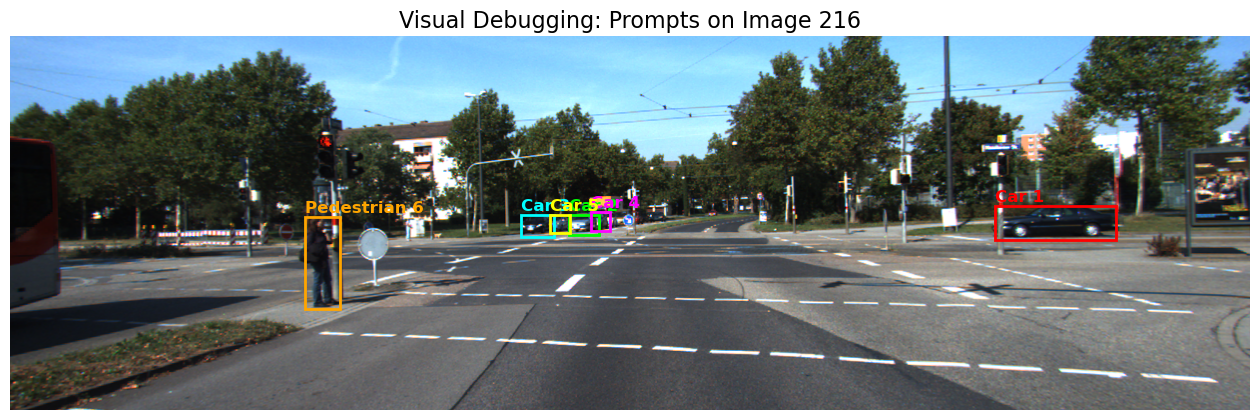

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

image_idx = 216 # Change this to find the perfect car or pedestrian!
image, target = val_dataset[image_idx]

# 1. Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.imshow(image)
ax.set_title(f"Visual Debugging: Prompts on Image {image_idx}", fontsize=16)

# 2. Extract the data from your target and prompt_kwargs
boxes = target["boxes"].numpy()
labels = target["labels"].numpy()

print(boxes)

# The points are heavily nested: prompt_kwargs["input_points"][0] gets the list of objects
# extracted_points = prompt_kwargs["input_points"][0] 

# Define some distinct colors for the 5 objects
colors = ['red', 'lime', 'cyan', 'magenta', 'yellow', 'orange', 'white']

# 3. Loop through each object and draw its box and points
for i in range(len(boxes)):
    box = boxes[i]
    color = colors[i % len(colors)] # Cycle colors if more than 7 objects
    
    # Draw Ground Truth Bounding Box
    x_min, y_min, x_max, y_max = box
    width = x_max - x_min
    height = y_max - y_min
    rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    
    # Draw the Prompts for this object
    # obj_pts = np.array(extracted_points[i]) # Shape: [Num_points, 2]
    # ax.scatter(obj_pts[:, 0], obj_pts[:, 1], c=color, s=100, edgecolors='black', marker='X', zorder=5)
    
    # Add a little label text
    class_name = "Car" if labels[i] == 3 else "Pedestrian"
    ax.text(x_min, y_min - 5, f"{class_name} {i+1}", color=color, fontsize=12, fontweight='bold')

plt.axis('off')
plt.show()

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


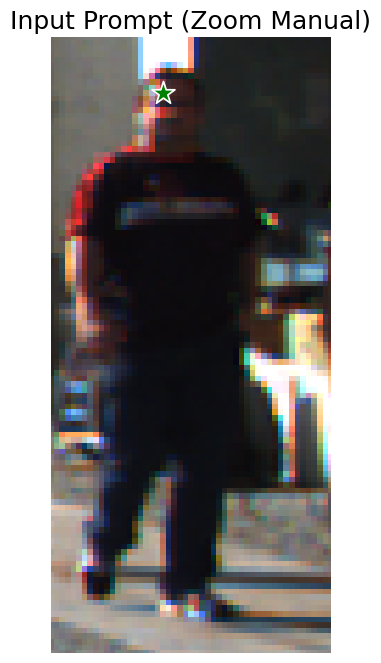

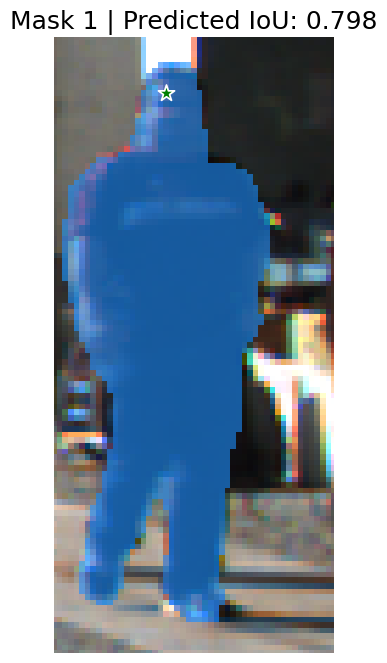

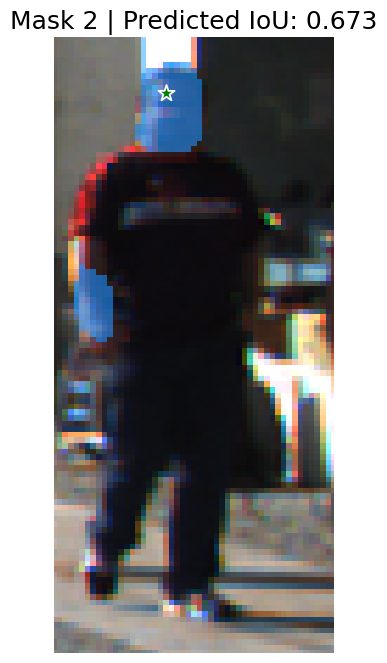

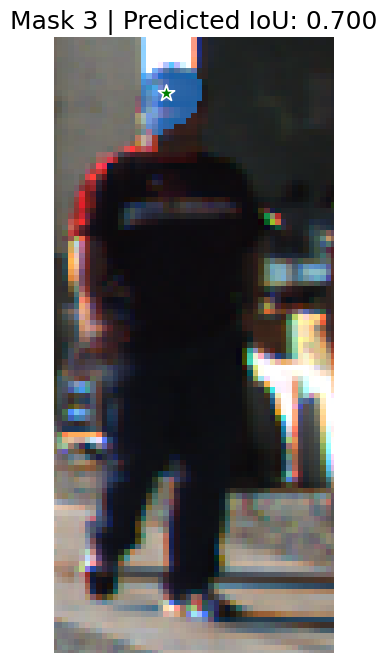

In [14]:
# 1. Select your image
image_idx = 2009 # Change this to find the perfect car or pedestrian!
image, target = val_dataset[image_idx]

# ==========================================
# EXPERIMENT CONTROL CENTER
# ==========================================
# Try 1 point (Tire) -> See Granularity
# Try 3 points (Tire, Window, Trunk) -> See Ambiguity Resolution
# Or try a bounding box!

# Example A: Single Point (e.g., on a tire)
# manual_points = [[[250, 180]]]
manual_points = [[[920, 160]]]
manual_labels = [[1]]
prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example B: Three Points (Uncomment to test Ambiguity Resolution)
# manual_points = [[[250, 180], [300, 150], [200, 160]]] 
# manual_labels = [[1, 1, 1]]
# prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example C: Bounding Box (Uncomment to test Task C's box collapse)
# manual_boxes = [[[150, 100, 350, 250]]] # [xmin, ymin, xmax, ymax]
# prompt_kwargs = {"input_boxes": manual_boxes}
# ==========================================

# 2. Run Inference Manually (Bypassing the wrapper's argmax filter)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 3. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] # Extract the batch [Num_Objects, 3, H, W]

scores = outputs.iou_scores[0].cpu() # Shape: [Num_Objects, 3]

# 4. Extract the 3 masks for our single object prompt
obj_idx = 0 
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# ==========================================
# DEFINE TU ZOOM MANUAL AQUÍ
# ==========================================
# x_min, y_min, width, height
mi_ventana_zoom = (900, 150, 50, 110) 

# 5. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=prompt_kwargs.get("input_points"),
    labels=prompt_kwargs.get("input_labels"),
    boxes=prompt_kwargs.get("input_boxes"),
    custom_window=mi_ventana_zoom  # <--- Pasas tu recuadro manual
)

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


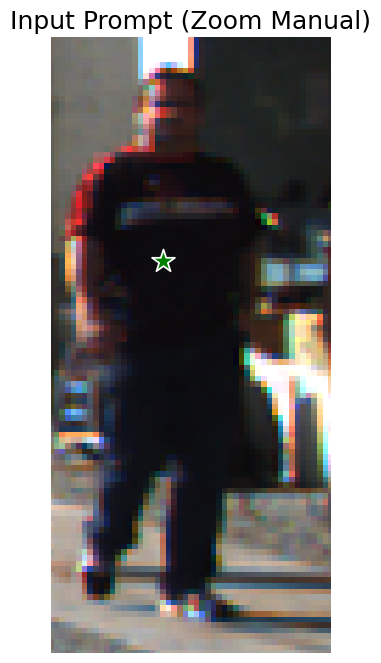

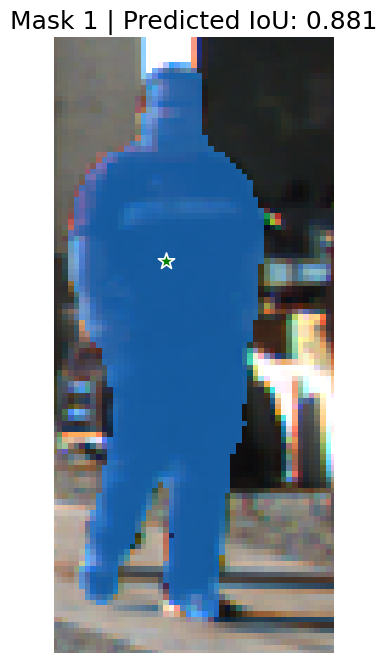

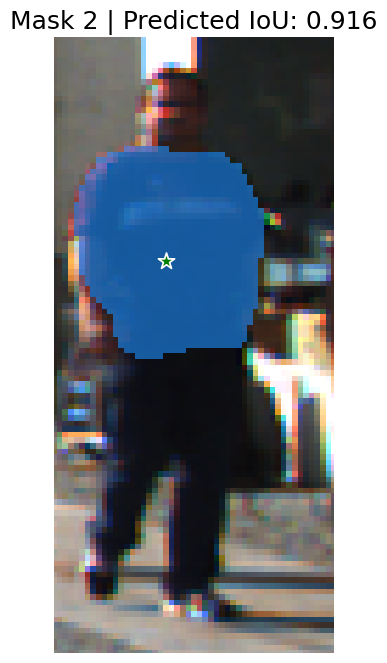

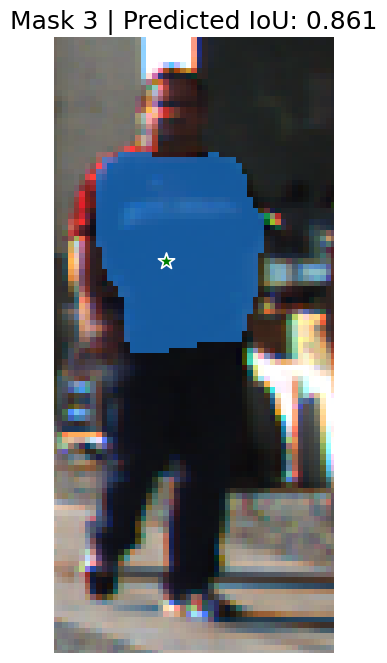

In [15]:
# 1. Select your image
image_idx = 2009 # Change this to find the perfect car or pedestrian!
image, target = val_dataset[image_idx]

# ==========================================
# EXPERIMENT CONTROL CENTER
# ==========================================
# Try 1 point (Tire) -> See Granularity
# Try 3 points (Tire, Window, Trunk) -> See Ambiguity Resolution
# Or try a bounding box!

# Example A: Single Point (e.g., on a tire)
# manual_points = [[[250, 180]]]
manual_points = [[[920, 190]]]
manual_labels = [[1]]
prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example B: Three Points (Uncomment to test Ambiguity Resolution)
# manual_points = [[[250, 180], [300, 150], [200, 160]]] 
# manual_labels = [[1, 1, 1]]
# prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example C: Bounding Box (Uncomment to test Task C's box collapse)
# manual_boxes = [[[150, 100, 350, 250]]] # [xmin, ymin, xmax, ymax]
# prompt_kwargs = {"input_boxes": manual_boxes}
# ==========================================

# 2. Run Inference Manually (Bypassing the wrapper's argmax filter)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 3. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] # Extract the batch [Num_Objects, 3, H, W]

scores = outputs.iou_scores[0].cpu() # Shape: [Num_Objects, 3]

# 4. Extract the 3 masks for our single object prompt
obj_idx = 0 
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# ==========================================
# DEFINE TU ZOOM MANUAL AQUÍ
# ==========================================
# x_min, y_min, width, height
mi_ventana_zoom = (900, 150, 50, 110) 

# 5. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=prompt_kwargs.get("input_points"),
    labels=prompt_kwargs.get("input_labels"),
    boxes=prompt_kwargs.get("input_boxes"),
    custom_window=mi_ventana_zoom  # <--- Pasas tu recuadro manual
)

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


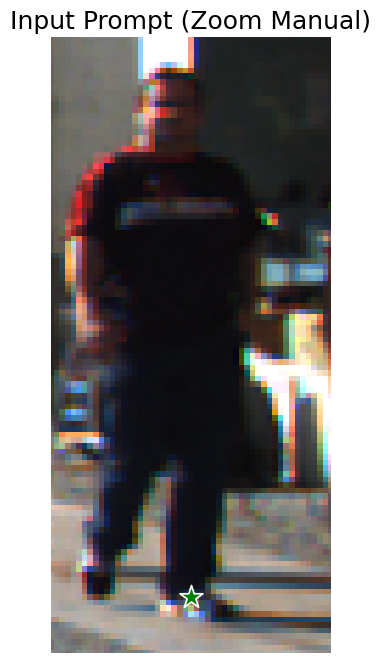

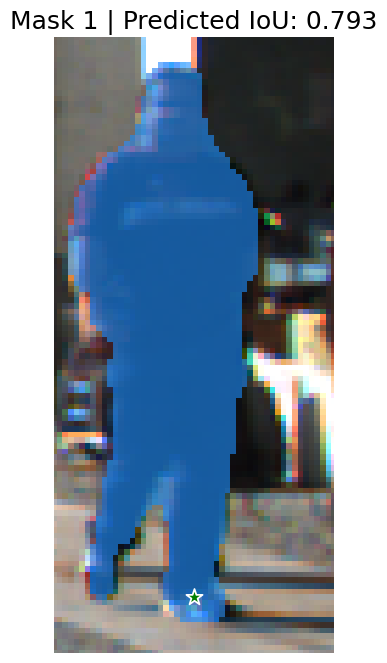

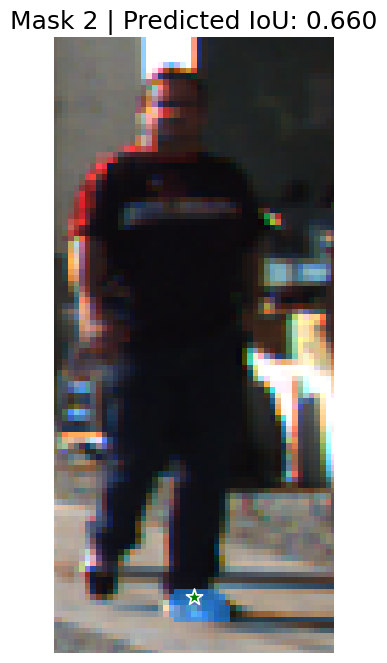

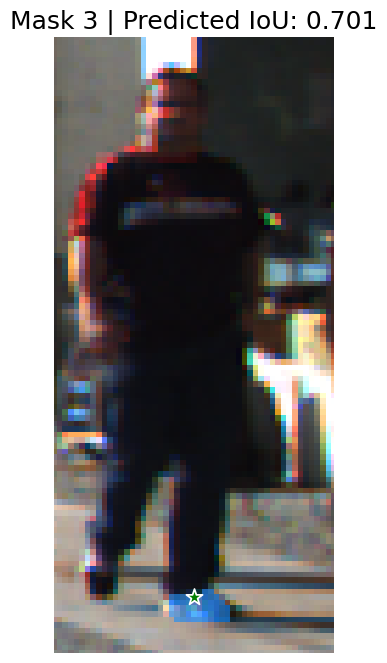

In [ ]:
# 1. Select your image
image_idx = 2009 # Change this to find the perfect car or pedestrian!
image, target = val_dataset[image_idx]

# ==========================================
# EXPERIMENT CONTROL CENTER
# ==========================================
# Try 1 point (Tire) -> See Granularity
# Try 3 points (Tire, Window, Trunk) -> See Ambiguity Resolution
# Or try a bounding box!

# Example A: Single Point (e.g., on a tire)
# manual_points = [[[250, 180]]]
manual_points = [[[920, 160]]]
manual_labels = [[1]]
prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example B: Three Points (Uncomment to test Ambiguity Resolution)
# manual_points = [[[250, 180], [300, 150], [200, 160]]] 
# manual_labels = [[1, 1, 1]]
# prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example C: Bounding Box (Uncomment to test Task C's box collapse)
# manual_boxes = [[[150, 100, 350, 250]]] # [xmin, ymin, xmax, ymax]
# prompt_kwargs = {"input_boxes": manual_boxes}
# ==========================================

# 2. Run Inference Manually (Bypassing the wrapper's argmax filter)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 3. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] # Extract the batch [Num_Objects, 3, H, W]

scores = outputs.iou_scores[0].cpu() # Shape: [Num_Objects, 3]

# 4. Extract the 3 masks for our single object prompt
obj_idx = 0 
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# ==========================================
# DEFINE TU ZOOM MANUAL AQUÍ
# ==========================================
# x_min, y_min, width, height
mi_ventana_zoom = (900, 150, 50, 110) 

# 5. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=prompt_kwargs.get("input_points"),
    labels=prompt_kwargs.get("input_labels"),
    boxes=prompt_kwargs.get("input_boxes"),
    custom_window=mi_ventana_zoom  # <--- Pasas tu recuadro manual
)

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


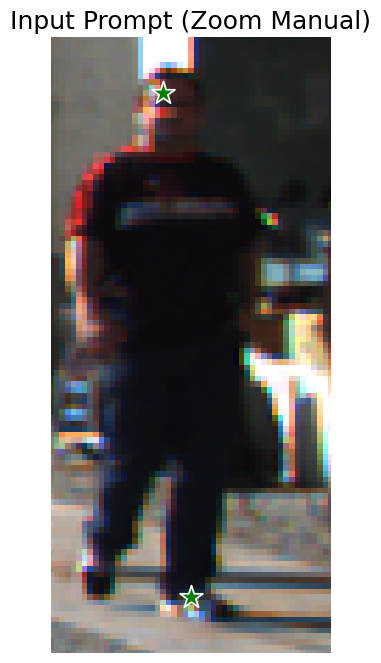

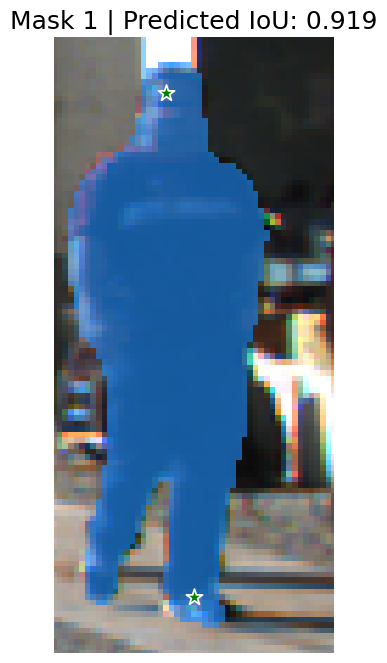

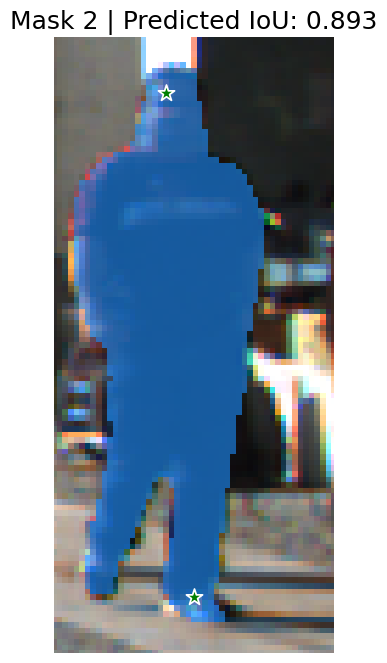

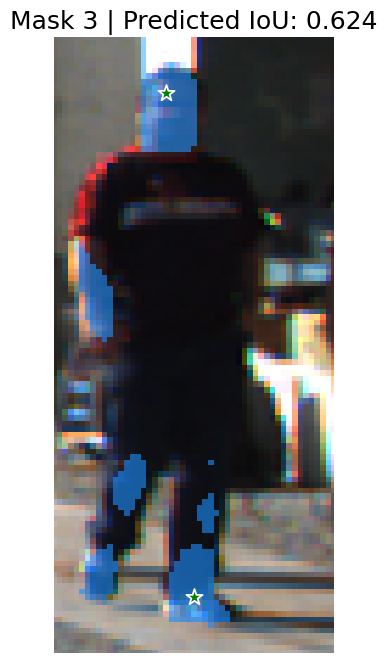

In [13]:
# 1. Select your image
image_idx = 2009 # Change this to find the perfect car or pedestrian!
image, target = val_dataset[image_idx]

# ==========================================
# EXPERIMENT CONTROL CENTER
# ==========================================
# Try 1 point (Tire) -> See Granularity
# Try 3 points (Tire, Window, Trunk) -> See Ambiguity Resolution
# Or try a bounding box!

# Example A: Single Point (e.g., on a tire)
# manual_points = [[[925, 250]]]
# manual_labels = [[1]]
# prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example B: Three Points (Uncomment to test Ambiguity Resolution)
manual_points = [[[925, 250],  [920, 160]]]  #[920, 190],
manual_labels = [[1, 1]]
prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example C: Bounding Box (Uncomment to test Task C's box collapse)
# manual_boxes = [[[150, 100, 350, 250]]] # [xmin, ymin, xmax, ymax]
# prompt_kwargs = {"input_boxes": manual_boxes}
# ==========================================

# 2. Run Inference Manually (Bypassing the wrapper's argmax filter)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 3. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] # Extract the batch [Num_Objects, 3, H, W]

scores = outputs.iou_scores[0].cpu() # Shape: [Num_Objects, 3]

# 4. Extract the 3 masks for our single object prompt
obj_idx = 0 
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# ==========================================
# DEFINE TU ZOOM MANUAL AQUÍ
# ==========================================
# x_min, y_min, width, height
mi_ventana_zoom = (900, 150, 50, 110) 

# 5. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=prompt_kwargs.get("input_points"),
    labels=prompt_kwargs.get("input_labels"),
    boxes=prompt_kwargs.get("input_boxes"),
    custom_window=mi_ventana_zoom  # <--- Pasas tu recuadro manual
)

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


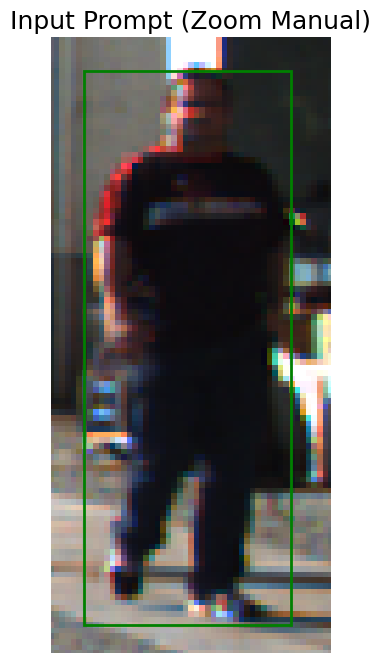

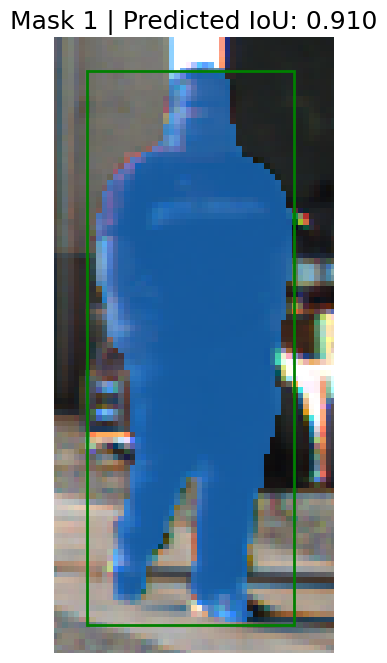

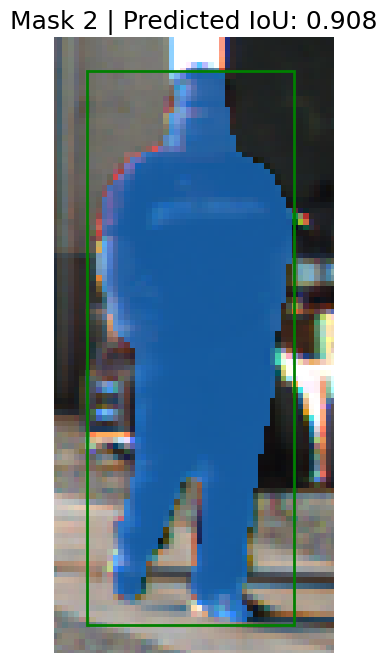

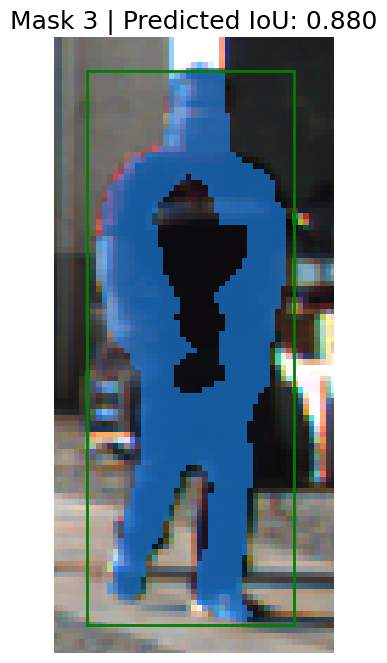

In [20]:
# 1. Select your image
image_idx = 2009 # Change this to find the perfect car or pedestrian!
image, target = val_dataset[image_idx]

# ==========================================
# EXPERIMENT CONTROL CENTER
# ==========================================
# Try 1 point (Tire) -> See Granularity
# Try 3 points (Tire, Window, Trunk) -> See Ambiguity Resolution
# Or try a bounding box!

# Example A: Single Point (e.g., on a tire)
# manual_points = [[[250, 180]]]
# manual_points = [[[120, 250]]] 
# manual_labels = [[1]]
# prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# # Example B: Three Points (Uncomment to test Ambiguity Resolution)
# manual_points = [[[230, 200], [180, 260], [280, 200]]] 
# manual_labels = [[1, 1, 1]]
# prompt_kwargs = {"input_points": manual_points, "input_labels": manual_labels}

# Example C: Bounding Box (Uncomment to test Task C's box collapse)
manual_boxes = [[[901 , 156, 938, 255]]] # [xmin, ymin, xmax, ymax]
prompt_kwargs = {"input_boxes": manual_boxes}
# ==========================================

# 2. Run Inference Manually (Bypassing the wrapper's argmax filter)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 3. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] # Extract the batch [Num_Objects, 3, H, W]

scores = outputs.iou_scores[0].cpu() # Shape: [Num_Objects, 3]

# 4. Extract the 3 masks for our single object prompt
obj_idx = 0 
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# # 5. Plot the Granularity / Ambiguity Grid!
# plot_ambiguity_grid(
#     image=image,
#     masks=masks_to_plot,
#     scores=scores_to_plot,
#     points=prompt_kwargs.get("input_points"),
#     labels=prompt_kwargs.get("input_labels"),
#     boxes=prompt_kwargs.get("input_boxes"),
#     title=f"SAM Granularity Analysis | Image {image_idx}"
# )

# x_min, y_min, width, height
mi_ventana_zoom = (895, 150, 50, 110) 

# 5. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=prompt_kwargs.get("input_points"),
    labels=prompt_kwargs.get("input_labels"),
    boxes=prompt_kwargs.get("input_boxes"),
    custom_window=mi_ventana_zoom  # <--- Pasas tu recuadro manual
)

# SIFT


/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


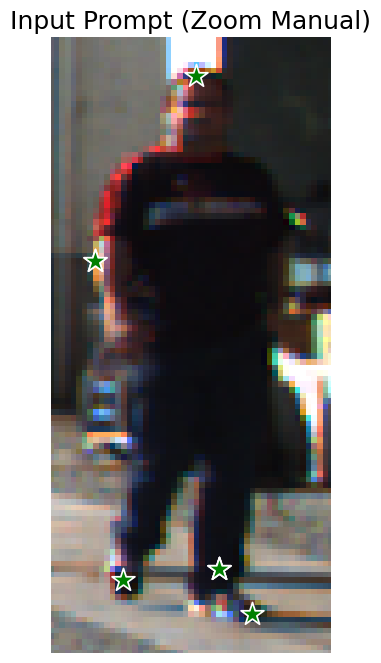

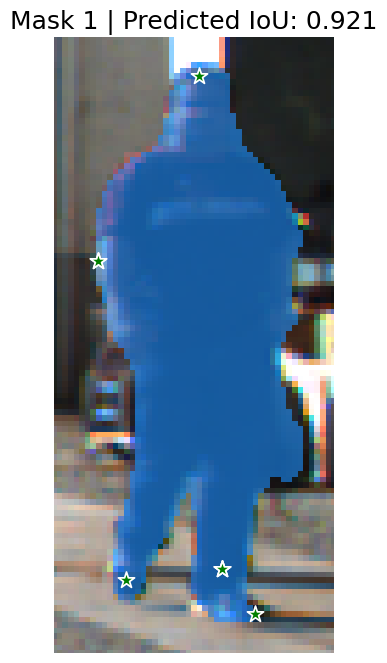

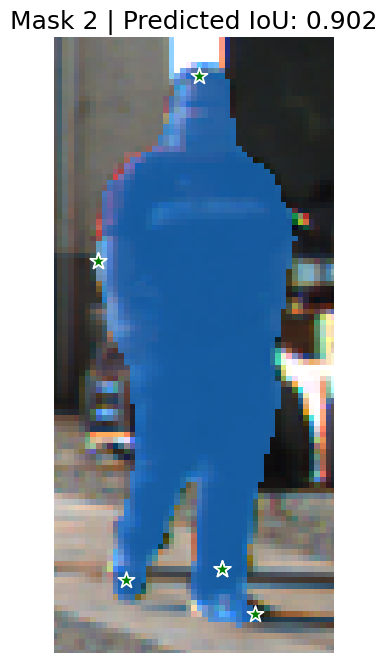

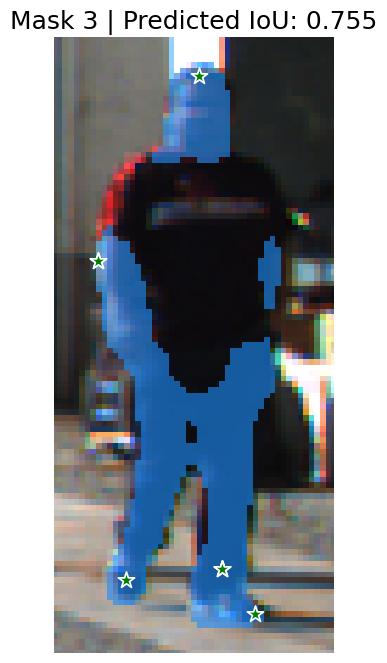

In [10]:
import torch
import numpy as np
from src.prompts import get_prompts

# 1. Select an image
image_idx = 2009  # Change to explore different images
image, target = val_dataset[image_idx]

# 2. Extract SIFT Prompts automatically
# Convert PIL image to numpy for OpenCV SIFT
image_np = np.array(image)

# Let's extract 1 SIFT point per object
config_sift = {"num_points": 8} 
prompt_kwargs, pred_labels = get_prompts(
    target, 
    prompt_type="sift_point", 
    config=config_sift, 
    image_np=image_np
)


# 3. Run Inference Manually (Bypassing the wrapper to keep all 3 masks)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 4. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] 

scores = outputs.iou_scores[0].cpu() 

# 5. Pick an object to visualize (e.g., the first object detected in the image)
# If the image has 5 cars, obj_idx = 0 is the first car, obj_idx = 1 is the second, etc.
obj_idx = 0 
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# Extract the specific SIFT point and label for this exact object
# prompt_kwargs format is heavily nested, so we unpack it carefully for the plotter
obj_points = [prompt_kwargs["input_points"][0][obj_idx]]
obj_labels = [prompt_kwargs["input_labels"][0][obj_idx]]

# x_min, y_min, width, height
mi_ventana_zoom = (895, 150, 50, 110) 

# 5. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=obj_points,
    labels=obj_labels,
    boxes=prompt_kwargs.get("input_boxes"),
    custom_window=mi_ventana_zoom  # <--- Pasas tu recuadro manual
)

# GRID (AYUDA CON LO QUE SIFT NO DETECTA)

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0013/000022.png


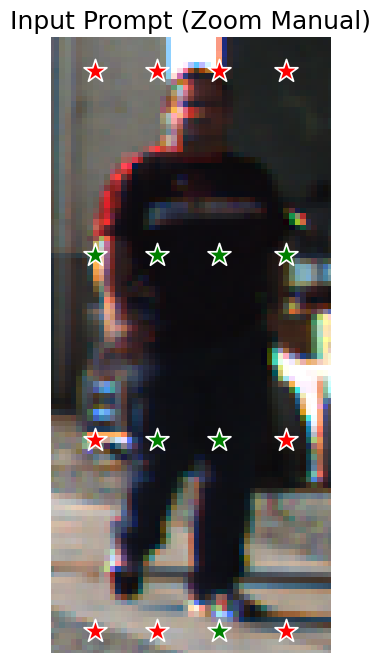

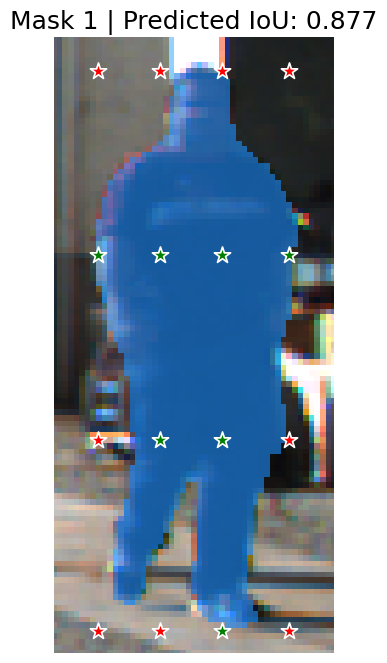

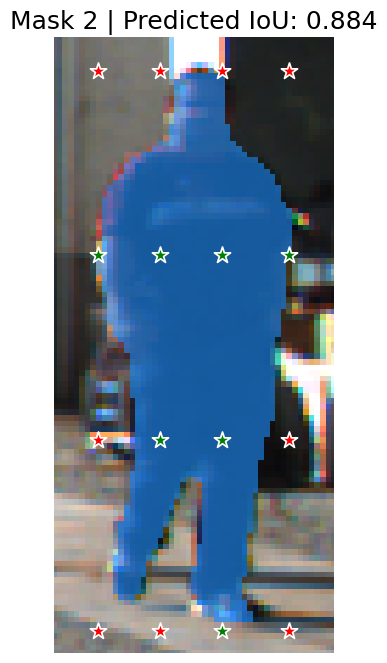

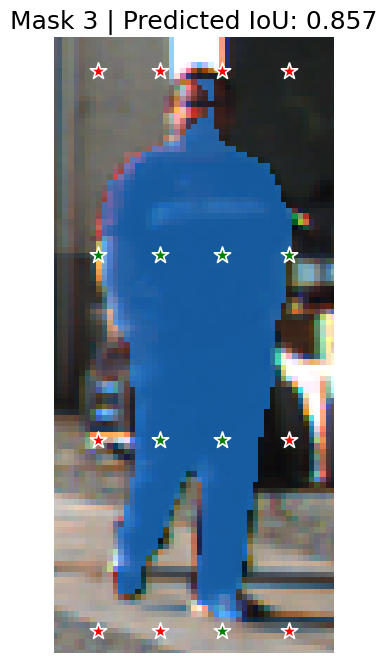

In [15]:
import torch
import numpy as np
from src.prompts import get_prompts

# 1. Select an image (Image 165 from your previous test is a great choice!)
image_idx = 2009  
image, target = val_dataset[image_idx]

# 2. Extract Grid Prompts automatically
# grid_size=3 means 9 points per object (3x3 grid)
config_grid = {"grid_size": 4} 
prompt_kwargs, pred_labels = get_prompts(
    target, 
    prompt_type="grid_point", 
    config=config_grid
)

# 3. Run Inference Manually (Bypassing the wrapper to keep all 3 masks)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 4. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] 

scores = outputs.iou_scores[0].cpu() 

# 5. Pick an object to visualize (e.g., obj_idx = 0)
obj_idx = 0
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# Extract the specific Grid points (9 points) and labels for this exact object
obj_points = [prompt_kwargs["input_points"][0][obj_idx]]
obj_labels = [prompt_kwargs["input_labels"][0][obj_idx]]

# ==========================================
# DEFINE TU ZOOM MANUAL AQUÍ
# ==========================================
# x_min, y_min, width, height
mi_ventana_zoom = (895, 150, 50, 110) 

# 6. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=obj_points,
    labels=obj_labels,
    custom_window=mi_ventana_zoom  
)

# OTRO

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0002/000216.png


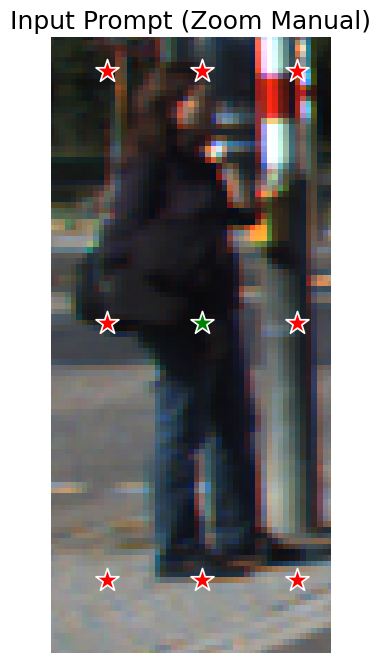

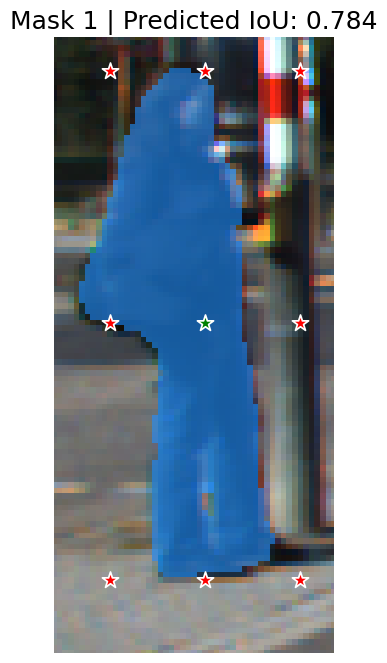

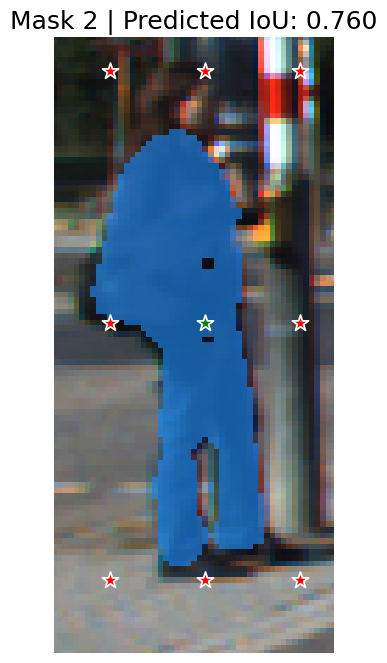

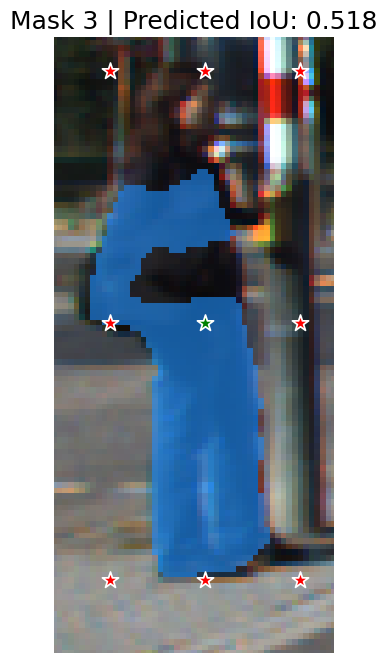

In [21]:
import torch
import numpy as np
from src.prompts import get_prompts

# 1. Select an image (Image 165 from your previous test is a great choice!)
image_idx = 216  
image, target = val_dataset[image_idx]

# 2. Extract Grid Prompts automatically
# grid_size=3 means 9 points per object (3x3 grid)
config_grid = {"grid_size": 3} 
prompt_kwargs, pred_labels = get_prompts(
    target, 
    prompt_type="grid_point", 
    config=config_grid
)

# 3. Run Inference Manually (Bypassing the wrapper to keep all 3 masks)
inputs = wrapper.processor(image, **prompt_kwargs, return_tensors="pt").to(device)

with torch.inference_mode():
    outputs = wrapper.model(**inputs)

# 4. Post-Process to original image size
processed_masks = wrapper.processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0] 

scores = outputs.iou_scores[0].cpu() 

# 5. Pick an object to visualize (e.g., obj_idx = 0)
obj_idx = 5
masks_to_plot = processed_masks[obj_idx].numpy() # Shape: [3, H, W]
scores_to_plot = scores[obj_idx].tolist()        # Shape: [3]

# Extract the specific Grid points (9 points) and labels for this exact object
obj_points = [prompt_kwargs["input_points"][0][obj_idx]]
obj_labels = [prompt_kwargs["input_labels"][0][obj_idx]]

# ==========================================
# DEFINE TU ZOOM MANUAL AQUÍ
# ==========================================
# x_min, y_min, width, height
mi_ventana_zoom = (285, 175, 50, 110) 

# 6. ¡Dibujar!
plot_custom_zoom_ambiguity(
    image=image,
    masks=masks_to_plot,
    scores=scores_to_plot,
    points=obj_points,
    labels=obj_labels,
    custom_window=mi_ventana_zoom  
)

/home/mcv/datasets/C5/KITTI-MOTS/training/image_02/0002/000216.png


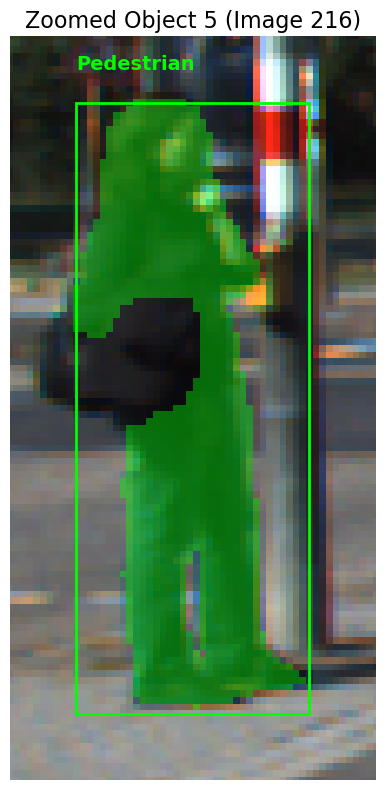

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Select Image and Object
image_idx = 216 # Change this to your target image
target_obj_idx = 5 # Change this to select which car/pedestrian to focus on (0, 1, 2...)
padding = 10 # Extra margin in pixels around the bounding box

image, target = val_dataset[image_idx]

# Convert PIL Image or Tensor to numpy array for plotting
if hasattr(image, 'numpy'):
    img_np = image.permute(1, 2, 0).numpy() if image.shape[0] == 3 else image.numpy()
else:
    img_np = np.array(image)

# Extract data
boxes = target["boxes"].numpy()
labels = target["labels"].numpy()
masks = target["masks"].numpy() # We grab the masks here!

# Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_np)
ax.set_title(f"Zoomed Object {target_obj_idx} (Image {image_idx})", fontsize=16)

# Check if the object index exists in this image
if len(boxes) > target_obj_idx:
    box = boxes[target_obj_idx]
    label = labels[target_obj_idx]
    mask = masks[target_obj_idx]
    
    x_min, y_min, x_max, y_max = box
    width = x_max - x_min
    height = y_max - y_min
    
    # 2. Draw Ground Truth Bounding Box
    rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    
    # 3. Overlay the Mask
    # Create an RGBA color mask (Lime green with 50% opacity)
    color_mask = np.zeros((*mask.shape, 4))
    color_mask[mask > 0] = [0, 1, 0, 0.4] # [R, G, B, Alpha]
    ax.imshow(color_mask)
    
    # Add a little label text
    class_name = "Car" if label == 3 else "Pedestrian"
    ax.text(x_min, y_min - 5, f"{class_name}", color='lime', fontsize=14, fontweight='bold')
    
    # 4. Apply the Zoom / Padding
    img_height, img_width = img_np.shape[:2]
    
    # Calculate limits with padding, ensuring we don't go outside the image borders
    xlim_min = max(0, x_min - padding)
    xlim_max = min(img_width, x_max + padding)
    ylim_min = max(0, y_min - padding)
    ylim_max = min(img_height, y_max + padding)
    
    # Set the axis limits to "zoom" in
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_max, ylim_min) # Y-axis is inverted in images!

else:
    print(f"Error: Object index {target_obj_idx} out of bounds. Found {len(boxes)} objects.")

plt.axis('off')
plt.tight_layout()
plt.show()